# Data Analysis in fake intership dataset 

This dataset presents a large-scale synthetic simulation of internship and job postings designed to model realistic recruitment behavior, phishing tactics, suspicious hiring patterns, and fraudulent employment activities across multiple industries.


Data source:https://www.kaggle.com/datasets/aiexplorer77/internship-scam-detection-dataset


### Objectives:
+ Detecting the fake internship post
+ Fake recuriment analysis

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

### Loading and basic overview of dataset 

+ 1000000 dataset with 33 columns 

In [30]:
df = pd.read_csv("../data/fake_internship_detection_dataset.csv")
df.head()

,posting_date,internship_title,employment_type,work_mode,industry,location,company_name,company_size,company_age,linkedin_presence,...,recruiter_experience_years,recruiter_email_type,suspicious_email_domain,recruiter_response_time_hours,social_media_presence,emotional_manipulation_score,phishing_language_score,trust_signal_score,fraud_score,is_fake_posting
0,2026-09-10,ML Engineer,Internship,Remote,Marketing,Berlin,"Russell, Medina and Evans",Startup,23.0,1,...,0.3,Free,1,17.6,1,12,28,48.4,51.8,1
1,2020-05-10,UI/UX Designer,Contract,Onsite,Marketing,Bangalore,Hays-White,Startup,12.0,0,...,5.1,Free,1,30.2,1,9,27,47.6,75.3,1
2,2021-07-18,UI/UX Designer,Internship,Hybrid,Gaming,Toronto,"Obrien, Gonzalez and Harris",Small,10.0,1,...,6.0,Free,1,12.5,0,26,18,98.8,0.0,0
3,2021-02-04,UI/UX Designer,Part-Time,Remote,AI,Berlin,"Martinez, Odonnell and Davidson",Enterprise,33.0,1,...,3.8,Corporate,0,24.6,1,20,0,72.2,11.0,0
4,2020-12-31,AI Research Intern,Internship,Onsite,EdTech,Toronto,Garcia-Owens,Small,14.0,0,...,7.0,Free,1,30.3,0,16,50,34.4,56.0,1


In [3]:
df.columns

Index(['posting_date', 'internship_title', 'employment_type', 'work_mode',
       'industry', 'location', 'company_name', 'company_size', 'company_age',
       'linkedin_presence', 'website_available', 'domain_age_months',
       'verification_status', 'stipend', 'unrealistic_salary_flag',
       'payment_required', 'registration_fee', 'job_description_length',
       'grammatical_errors', 'vague_description_score', 'urgency_score',
       'keyword_spam_score', 'fake_certificate_offer',
       'recruiter_experience_years', 'recruiter_email_type',
       'suspicious_email_domain', 'recruiter_response_time_hours',
       'social_media_presence', 'emotional_manipulation_score',
       'phishing_language_score', 'trust_signal_score', 'fraud_score',
       'is_fake_posting'],
      dtype='str')

In [5]:
df.shape 

(1000000, 33)

In [6]:
df.isnull().sum()


posting_date                         0
internship_title                     0
employment_type                      0
work_mode                            0
industry                             0
location                             0
company_name                         0
company_size                         0
company_age                      10000
linkedin_presence                    0
website_available                    0
domain_age_months                    0
verification_status                  0
stipend                          10000
unrealistic_salary_flag              0
payment_required                     0
registration_fee                     0
job_description_length               0
grammatical_errors                   0
vague_description_score              0
urgency_score                        0
keyword_spam_score                   0
fake_certificate_offer               0
recruiter_experience_years           0
recruiter_email_type                 0
suspicious_email_domain  

In [5]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.head(2)

,posting_date,internship_title,employment_type,work_mode,industry,location,company_name,company_size,company_age,linkedin_presence,...,recruiter_experience_years,recruiter_email_type,suspicious_email_domain,recruiter_response_time_hours,social_media_presence,emotional_manipulation_score,phishing_language_score,trust_signal_score,fraud_score,is_fake_posting
0,2026-09-10,ML Engineer,Internship,Remote,Marketing,Berlin,"Russell, Medina and Evans",Startup,23.0,1,...,0.3,Free,1,17.6,1,12,28,48.4,51.8,1
1,2020-05-10,UI/UX Designer,Contract,Onsite,Marketing,Bangalore,Hays-White,Startup,12.0,0,...,5.1,Free,1,30.2,1,9,27,47.6,75.3,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 33 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   posting_date                   1000000 non-null  str    
 1   internship_title               1000000 non-null  str    
 2   employment_type                1000000 non-null  str    
 3   work_mode                      1000000 non-null  str    
 4   industry                       1000000 non-null  str    
 5   location                       1000000 non-null  str    
 6   company_name                   1000000 non-null  str    
 7   company_size                   1000000 non-null  str    
 8   company_age                    990000 non-null   float64
 9   linkedin_presence              1000000 non-null  int64  
 10  website_available              1000000 non-null  int64  
 11  domain_age_months              1000000 non-null  int64  
 12  verification_status       

In [4]:
str_col = df.select_dtypes(['object','string']).columns
num = df.select_dtypes(['int','float']).columns
print(str_col)
print(num)

Index(['posting_date', 'internship_title', 'employment_type', 'work_mode',
       'industry', 'location', 'company_name', 'company_size',
       'recruiter_email_type'],
      dtype='str')
Index(['company_age', 'linkedin_presence', 'website_available',
       'domain_age_months', 'verification_status', 'stipend',
       'unrealistic_salary_flag', 'payment_required', 'registration_fee',
       'job_description_length', 'grammatical_errors',
       'vague_description_score', 'urgency_score', 'keyword_spam_score',
       'fake_certificate_offer', 'recruiter_experience_years',
       'suspicious_email_domain', 'recruiter_response_time_hours',
       'social_media_presence', 'emotional_manipulation_score',
       'phishing_language_score', 'trust_signal_score', 'fraud_score',
       'is_fake_posting'],
      dtype='str')


### Univaraiant data analysis

#### Posting date: insternship posting date
+ 2018-26 posting date.
+ Each year almost equal number of intership post are made.

In [17]:
df["posting_date"] =pd.to_datetime(df["posting_date"]) 

In [21]:
year = df["posting_date"].dt.year 
year.describe()

count    1000000.000000
mean        2022.002117
std            2.580357
min         2018.000000
25%         2020.000000
50%         2022.000000
75%         2024.000000
max         2026.000000
Name: posting_date, dtype: float64

In [22]:
year.value_counts()

posting_date
2023    111637
2021    111231
2024    111189
2022    111165
2019    111087
2026    111058
2025    111004
2020    110933
2018    110696
Name: count, dtype: int64

### Intership title:
+ 9 intership title
+ Most of the post are made for marketing intern and few post are made for data science intern

In [24]:
df["internship_title"].describe()

count              1000000
unique                   9
top       Marketing Intern
freq                111577
Name: internship_title, dtype: object

In [23]:
df["internship_title"].value_counts()

internship_title
Marketing Intern         111577
Cloud Engineer           111482
AI Research Intern       111441
Cybersecurity Analyst    111399
UI/UX Designer           111394
Backend Developer        110928
ML Engineer              110686
Frontend Developer       110591
Data Science Intern      110502
Name: count, dtype: int64

##### Piechart visualization of internship title

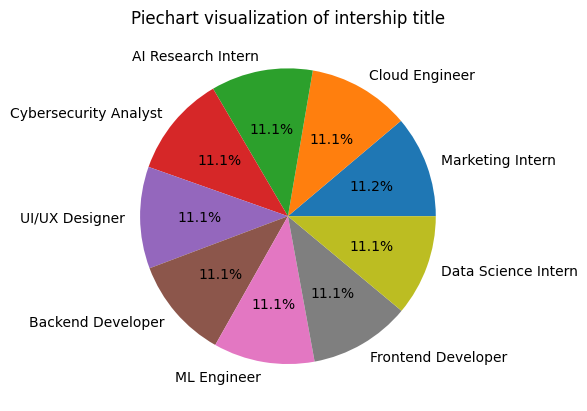

In [35]:
plt.title("Piechart visualization of intership title")
plt.pie(x=df["internship_title"].value_counts(),labels=df["internship_title"].value_counts().index,autopct="%1.1f%%")
plt.show()

### Employment types 
+ For each type of employment equal number of post are made 

In [36]:
df["employment_type"].value_counts()

employment_type
Part-Time     250700
Internship    249998
Contract      249669
Full-Time     249633
Name: count, dtype: int64

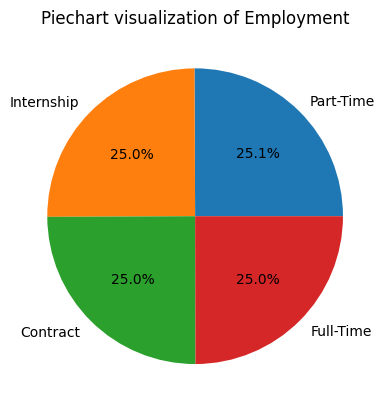

In [37]:
plt.title("Piechart visualization of Employment")
plt.pie(x=df["employment_type"].value_counts(),labels=df["employment_type"].value_counts().index,autopct="%1.1f%%")
plt.show()

### Work mode 
+ More then 50% post are made for remote job 

In [53]:
df["work_mode"].value_counts(normalize=True)*100

work_mode
Remote    54.9339
Hybrid    25.0526
Onsite    20.0135
Name: proportion, dtype: float64

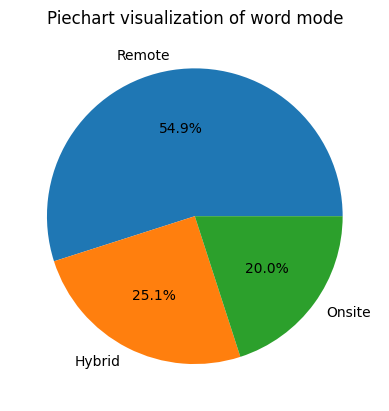

In [39]:
plt.title("Piechart visualization of word mode")
plt.pie(x=df["work_mode"].value_counts(),labels=df["work_mode"].value_counts().index, autopct="%1.1f%%")
plt.show()

### Industry 

In [40]:
df["industry"].value_counts()

industry
AI               111803
EdTech           111417
Healthcare       111357
FinTech          111025
E-Commerce       111016
Marketing        111005
Gaming           110967
Cybersecurity    110878
Software         110532
Name: count, dtype: int64

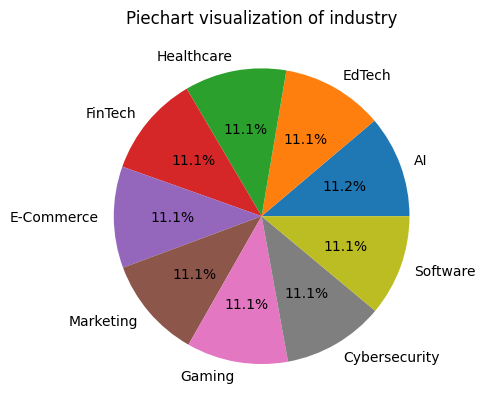

In [41]:
plt.title("Piechart visualization of industry")
plt.pie(x=df["industry"].value_counts(),labels=df["industry"].value_counts().index,autopct = "%1.1f%%")
plt.show()

### Location 


In [42]:
df["location"].value_counts()

location
Sydney           111520
Toronto          111477
Bangalore        111441
San Francisco    111390
Berlin           110990
Dubai            110987
Singapore        110882
London           110754
New York         110559
Name: count, dtype: int64

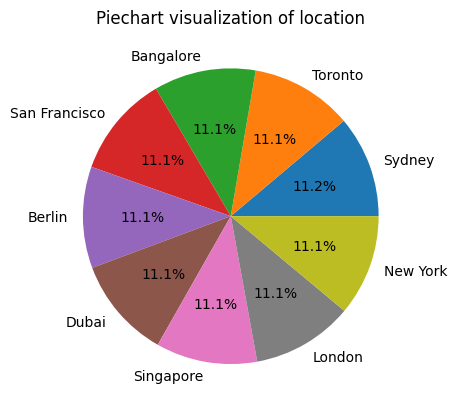

In [43]:
plt.title("Piechart visualization of location")
plt.pie(x=df["location"].value_counts(),labels=df["location"].value_counts().index,autopct = "%1.1f%%")
plt.show()

### Company size

+ Most of the internship and job post are made by small and startup company
+ Large and enterprise company made a fewest post

In [47]:
df["company_size"].value_counts()

company_size
Small         300184
Startup       299863
Medium        249593
Enterprise    150360
Name: count, dtype: int64

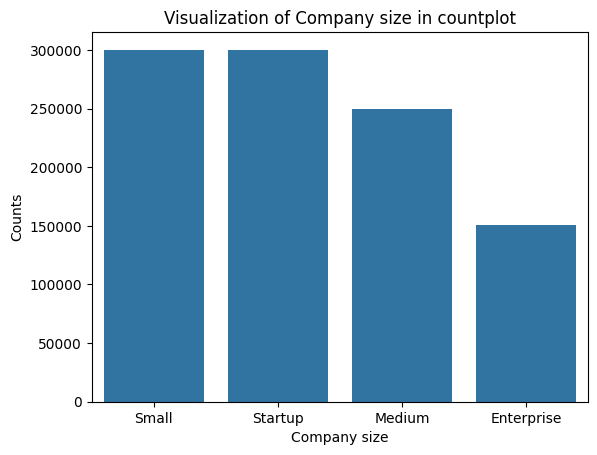

In [54]:
plt.title("Visualization of Company size in countplot")
plt.xlabel("Company size")
plt.ylabel("Counts")
sns.countplot(order=df["company_size"].value_counts().index,data=df,x="company_size")
plt.show()

### Company age 
+ 1% data i.e 10000 are missing.

In [55]:
df["company_age"].isnull().sum()

np.int64(10000)

In [56]:
df["company_age"].describe()

count    990000.000000
mean         20.000174
std          11.252082
min           1.000000
25%          10.000000
50%          20.000000
75%          30.000000
max          39.000000
Name: company_age, dtype: float64

### Linkedin presence 
+ 80% of company have presence in linkedin

In [3]:
df["linkedin_presence"].value_counts()

linkedin_presence
1    800764
0    199236
Name: count, dtype: int64

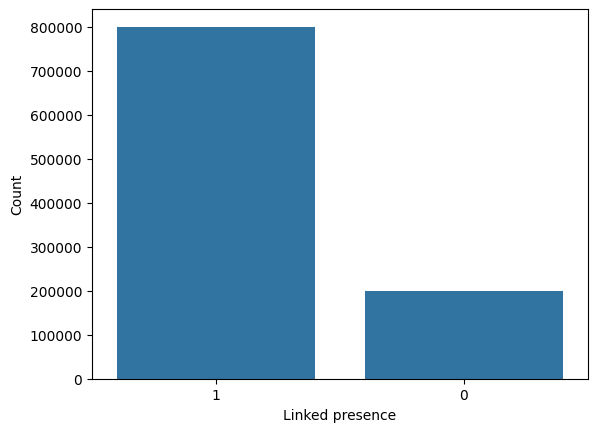

In [6]:
plt.xlabel("Linked presence")
plt.ylabel("Count")
sns.countplot(x="linkedin_presence",data=df,order=df["linkedin_presence"].value_counts().index)
plt.show()

### Website available 
+ More then 80% company have website

In [7]:
df["website_available"].value_counts()

website_available
1    849597
0    150403
Name: count, dtype: int64

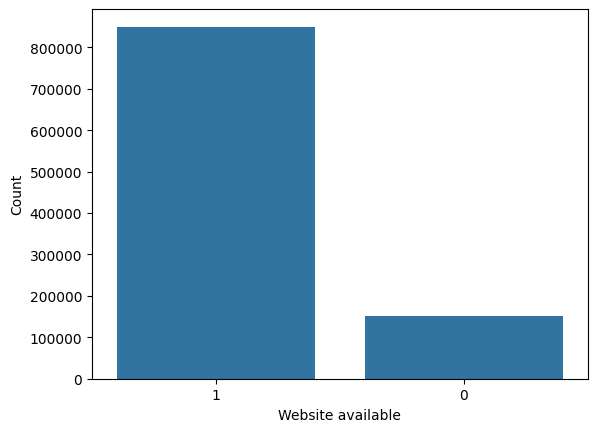

In [8]:
plt.xlabel("Website available")
plt.ylabel("Count")
sns.countplot(x="website_available",data=df,order=df["website_available"].value_counts().index)
plt.show()

### Domain age months

In [11]:
df["domain_age_months"].describe()

count    1000000.000000
mean         239.541209
std          135.737891
min            1.000000
25%          123.000000
50%          240.000000
75%          356.000000
max          500.000000
Name: domain_age_months, dtype: float64

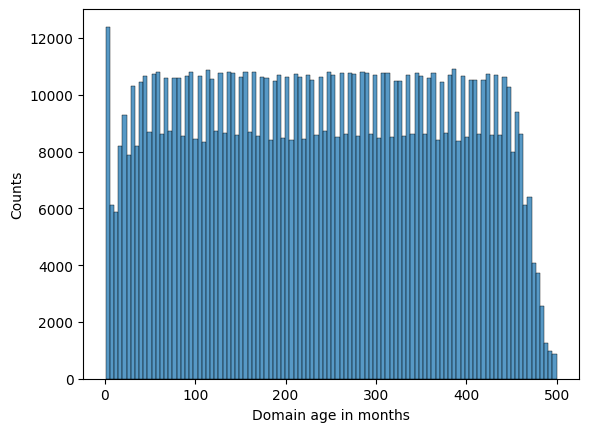

In [14]:
plt.xlabel("Domain age in months")
plt.ylabel("Counts")
sns.histplot(data=df,x="domain_age_months")
plt.show()

### Verification status
+ This column usally indicate that intership post is varified or not
+ Almost 70% post are verified

In [16]:
df["verification_status"].value_counts()

verification_status
1    699713
0    300287
Name: count, dtype: int64

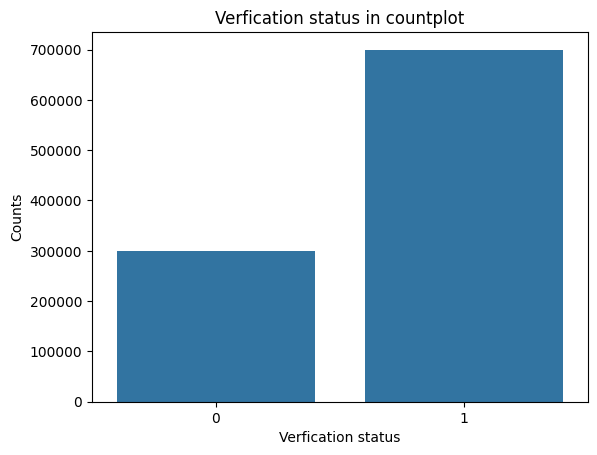

In [23]:
plt.title("Verfication status in countplot")
plt.xlabel("Verfication status")
plt.ylabel("Counts")
sns.countplot(x="verification_status",data=df)
plt.show()

### Stipend 
+ Offer salary 

In [21]:
df["stipend"].describe()

count    990000.000000
mean      35066.198206
std       14830.059509
min        2000.000000
25%       24841.000000
50%       34984.000000
75%       45124.000000
max      110428.000000
Name: stipend, dtype: float64

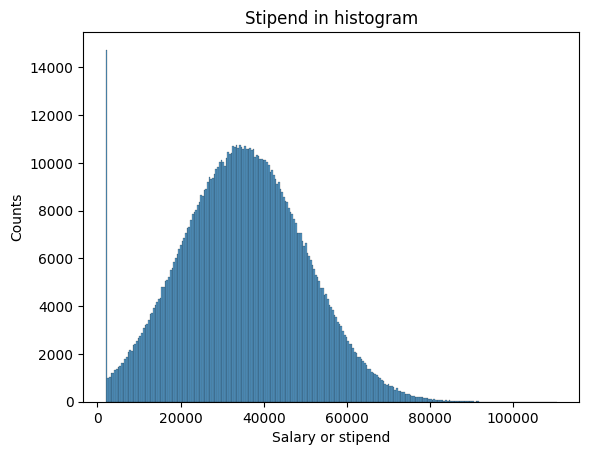

In [22]:
plt.title("Stipend in histogram")
plt.xlabel("Salary or stipend")
plt.ylabel("Counts")
sns.histplot(x="stipend",data=df)
plt.show()

### Unrealistic salary flag
+ There is not any unrealistic salary offer from any internship post 

In [25]:
df["unrealistic_salary_flag"].value_counts()

unrealistic_salary_flag
0    1000000
Name: count, dtype: int64

### Payment requirement 
+ For 90% of internship  no payment is requirement 

In [30]:
df["payment_required"].value_counts(normalize=True)*100

payment_required
0    90.0095
1     9.9905
Name: proportion, dtype: float64

### Registration fee
+ 90% internship post doesn't charge registration fee
+ 4999 is the maximum charge for registration

In [40]:
df["registration_fee"].value_counts()[0]

np.int64(900095)

In [39]:
df["registration_fee"].describe()

count    1000000.000000
mean         252.083069
std          881.467489
min            0.000000
25%            0.000000
50%            0.000000
75%            0.000000
max         4999.000000
Name: registration_fee, dtype: float64

### Job description length
+ Maximum words is 5000 and minimum is 100 words 

In [41]:
df["job_description_length"].describe()

count    1000000.000000
mean        1799.538324
std          598.563156
min          100.000000
25%         1395.000000
50%         1799.000000
75%         2203.000000
max         5000.000000
Name: job_description_length, dtype: float64

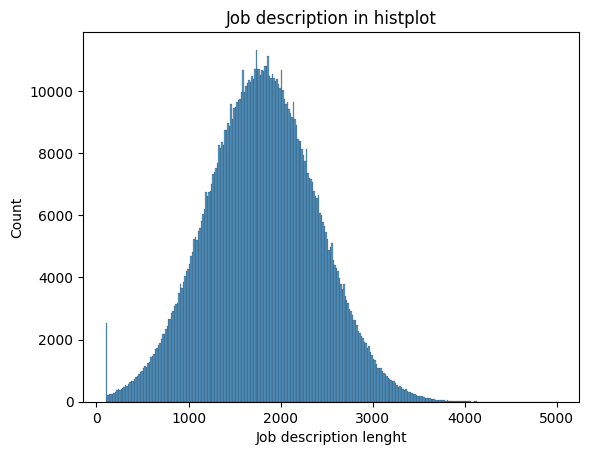

In [43]:
plt.title("Job description in histplot")
sns.histplot(x="job_description_length",data=df)
plt.xlabel("Job description lenght")
plt.ylabel("Count")
plt.show()

### Grammatical Errors 
+ Estimated number of grammatical issues detected in the posting

In [46]:
df["grammatical_errors"].describe()

count    1000000.000000
mean           2.998825
std            1.731828
min            0.000000
25%            2.000000
50%            3.000000
75%            4.000000
max           14.000000
Name: grammatical_errors, dtype: float64

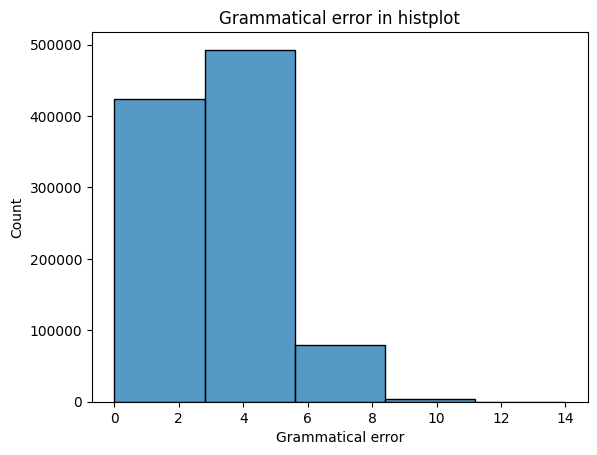

In [55]:
plt.title("Grammatical error in histplot")
sns.histplot(x="grammatical_errors",data=df,bins=5)
plt.xlabel("Grammatical error")
plt.ylabel("Count")
plt.show()

### Vague Description score 

In [3]:
df["vague_description_score"].describe()

count    1000000.000000
mean          30.132072
std           18.814980
min            0.000000
25%           16.000000
50%           30.000000
75%           43.000000
max          100.000000
Name: vague_description_score, dtype: float64

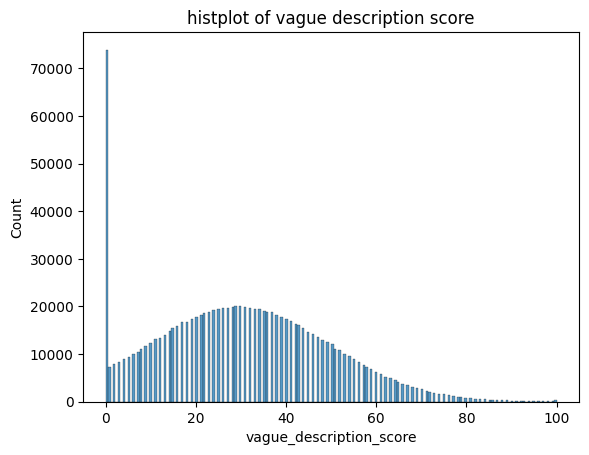

In [5]:
plt.title("histplot of vague description score")
sns.histplot(x="vague_description_score",data=df)
plt.show()

In [57]:
df["vague_description_score"].value_counts(normalize=True)*100

vague_description_score
0     7.3938
30    2.0168
29    2.0132
28    1.9869
31    1.9812
       ...  
95    0.0094
96    0.0079
97    0.0071
98    0.0053
99    0.0050
Name: proportion, Length: 101, dtype: float64

### Urgency score 

In [9]:
df["urgency_score"].describe()

count    1000000.000000
mean          40.047191
std           23.612605
min            0.000000
25%           23.000000
50%           39.000000
75%           56.000000
max          100.000000
Name: urgency_score, dtype: float64

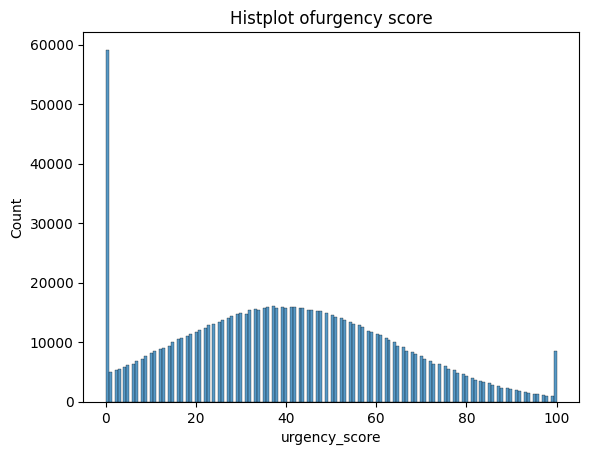

In [7]:
plt.title("Histplot of urgency score")
sns.histplot(x="urgency_score",data=df)
plt.show()

In [58]:
df["urgency_score"].value_counts(normalize=True)*100

urgency_score
0     5.9153
37    1.6007
39    1.5982
42    1.5949
41    1.5934
       ...  
95    0.1358
96    0.1223
97    0.1112
98    0.0967
99    0.0951
Name: proportion, Length: 101, dtype: float64

### Keyword spam score 

In [10]:
df["keyword_spam_score"].describe()


count    1000000.000000
mean          25.573860
std           18.116422
min            0.000000
25%           11.000000
50%           25.000000
75%           38.000000
max          100.000000
Name: keyword_spam_score, dtype: float64

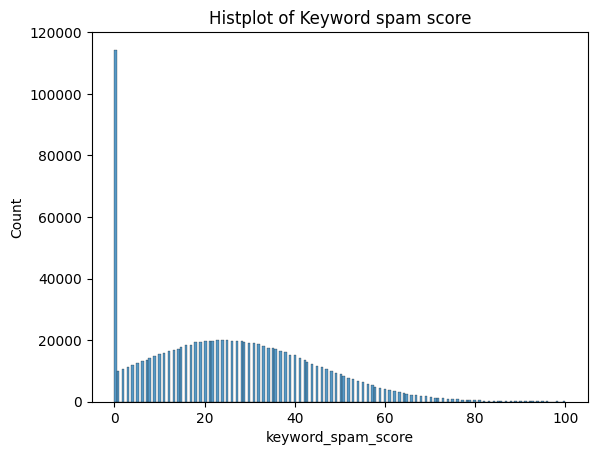

In [11]:
plt.title("Histplot of Keyword spam score")
sns.histplot(x="keyword_spam_score",data=df)
plt.show()

In [60]:
df["keyword_spam_score"].value_counts(normalize=True)*100

keyword_spam_score
0     11.4428
25     2.0122
24     1.9919
23     1.9880
22     1.9823
       ...   
95     0.0047
96     0.0033
98     0.0028
97     0.0018
99     0.0014
Name: proportion, Length: 101, dtype: float64

### Fake certification score 

In [13]:
df["fake_certificate_offer"].value_counts()

fake_certificate_offer
0    920170
1     79830
Name: count, dtype: int64

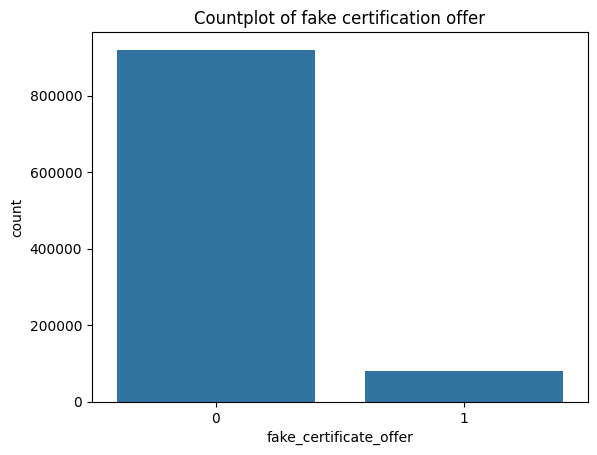

In [16]:
plt.title("Countplot of fake certification offer")
sns.countplot(x="fake_certificate_offer",data=df )
plt.show()

### Recruiter experience year 

In [17]:
df["recruiter_experience_years"].describe()

count    1000000.000000
mean           5.052660
std            2.871692
min            0.000000
25%            3.000000
50%            5.000000
75%            7.000000
max           19.600000
Name: recruiter_experience_years, dtype: float64

In [63]:
df["recruiter_experience_years"].value_counts(normalize=True)*100

recruiter_experience_years
0.0     4.9615
4.8     1.3407
5.1     1.3392
4.9     1.3379
5.0     1.3368
         ...  
19.6    0.0001
17.4    0.0001
17.7    0.0001
17.9    0.0001
18.1    0.0001
Name: proportion, Length: 183, dtype: float64

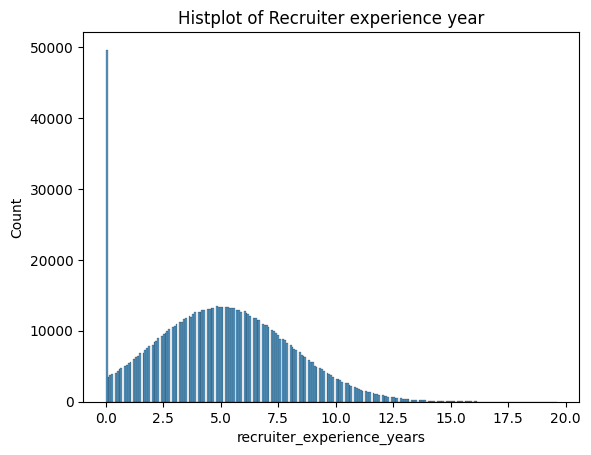

In [18]:
plt.title("Histplot of Recruiter experience year")
sns.histplot(x="recruiter_experience_years",data=df)
plt.show()

In [19]:
df["recruiter_experience_years"].value_counts()

recruiter_experience_years
0.0     49615
4.8     13407
5.1     13392
4.9     13379
5.0     13368
        ...  
19.6        1
17.4        1
17.7        1
17.9        1
18.1        1
Name: count, Length: 183, dtype: int64

### Recruiter email type 


In [20]:
df["recruiter_email_type"].value_counts()

recruiter_email_type
Corporate    749433
Free         250567
Name: count, dtype: int64

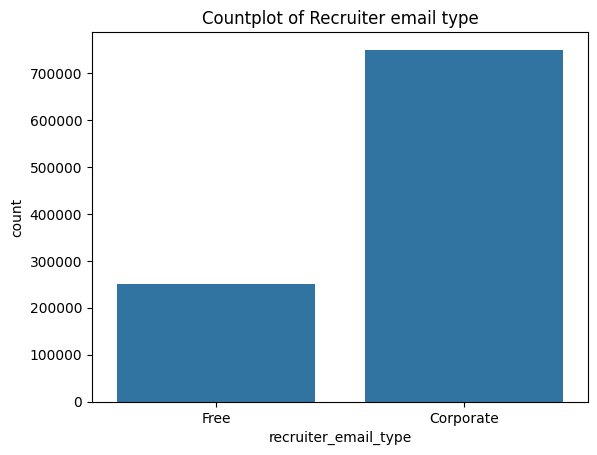

In [21]:
plt.title("Countplot of Recruiter email type")
sns.countplot(x="recruiter_email_type",data=df )
plt.show()

### Suspicious emial domain


In [22]:
df["suspicious_email_domain"].value_counts()

suspicious_email_domain
0    749433
1    250567
Name: count, dtype: int64

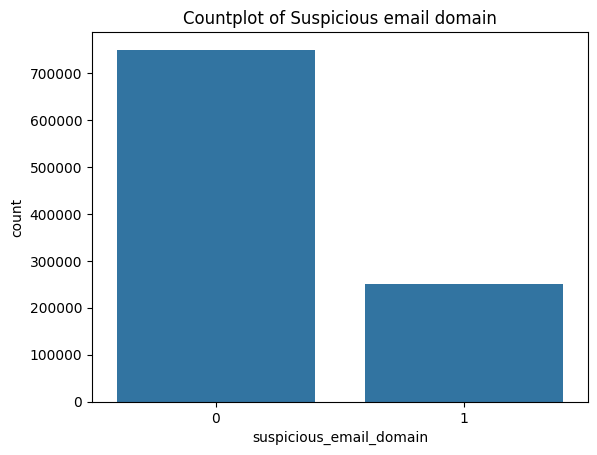

In [23]:
plt.title("Countplot of Suspicious email domain")
sns.countplot(x="suspicious_email_domain",data=df )
plt.show()

### Recruiter response time(in hours)

In [24]:
df["recruiter_response_time_hours"].describe()

count    1000000.000000
mean          18.180467
std            9.611051
min            1.000000
25%           11.200000
50%           18.000000
75%           24.800000
max           63.900000
Name: recruiter_response_time_hours, dtype: float64

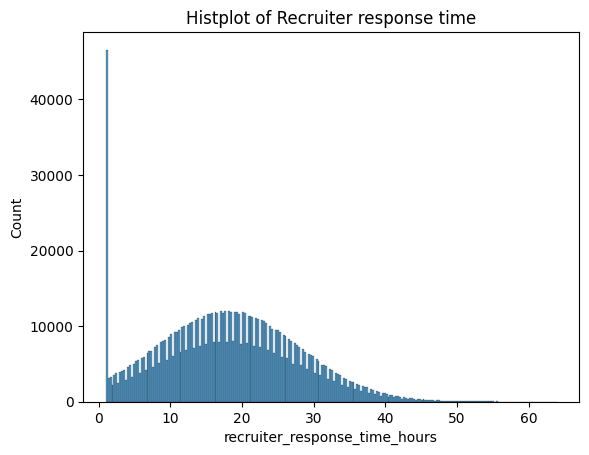

In [25]:
plt.title("Histplot of Recruiter response time")
sns.histplot(x="recruiter_response_time_hours",data=df)
plt.show()

In [65]:
df["recruiter_response_time_hours"].value_counts(normalize=True)*100

recruiter_response_time_hours
1.0     4.4700
18.8    0.4083
16.4    0.4071
18.1    0.4069
19.4    0.4053
         ...  
62.6    0.0001
60.7    0.0001
61.6    0.0001
57.2    0.0001
60.0    0.0001
Name: proportion, Length: 595, dtype: float64

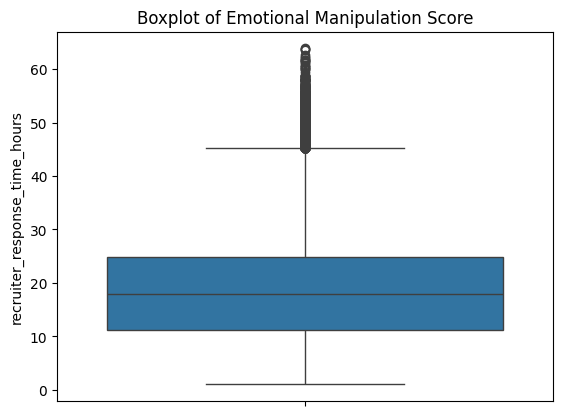

In [34]:
sns.boxplot(y=df['recruiter_response_time_hours'])
plt.title('Boxplot of Emotional Manipulation Score')
plt.show()

In [26]:
df["recruiter_response_time_hours"].value_counts()

recruiter_response_time_hours
1.0     44700
18.8     4083
16.4     4071
18.1     4069
19.4     4053
        ...  
62.6        1
60.7        1
61.6        1
57.2        1
60.0        1
Name: count, Length: 595, dtype: int64

### Social media presence 

In [27]:
df["social_media_presence"].value_counts()

social_media_presence
1    749800
0    250200
Name: count, dtype: int64

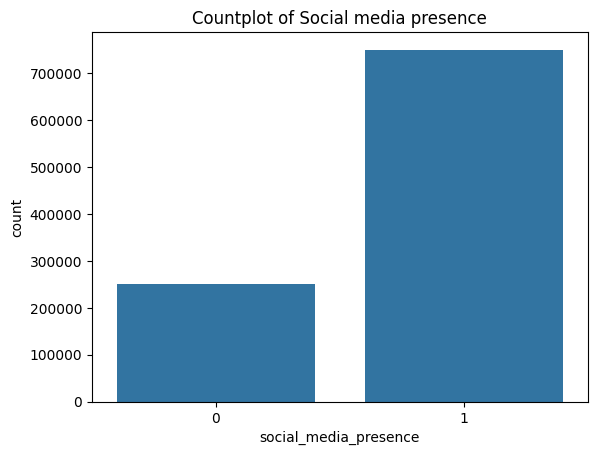

In [28]:
plt.title("Countplot of Social media presence")
sns.countplot(x="social_media_presence",data=df )
plt.show()

### Emptional manipulation score

In [29]:
df["emotional_manipulation_score"].describe()

count    1000000.000000
mean          25.563839
std           18.129998
min            0.000000
25%           11.000000
50%           24.000000
75%           38.000000
max          100.000000
Name: emotional_manipulation_score, dtype: float64

In [66]:
df["emotional_manipulation_score"].value_counts(normalize=True)*100

emotional_manipulation_score
0     11.4946
23     2.0142
26     2.0006
24     1.9967
27     1.9912
       ...   
95     0.0044
96     0.0043
97     0.0037
99     0.0025
98     0.0015
Name: proportion, Length: 101, dtype: float64

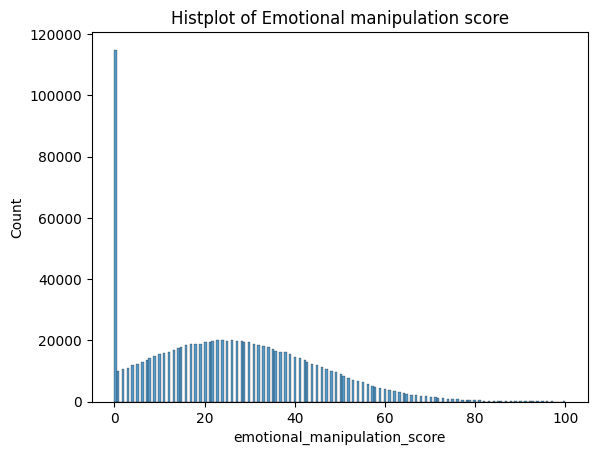

In [30]:
plt.title("Histplot of Emotional manipulation score")
sns.histplot(x="emotional_manipulation_score",data=df)
plt.show()

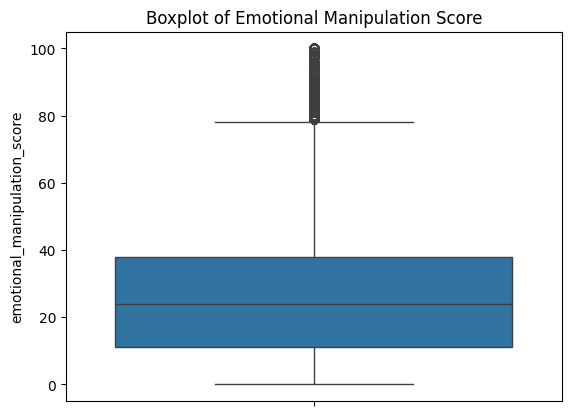

In [33]:
sns.boxplot(y=df['emotional_manipulation_score'])
plt.title('Boxplot of Emotional Manipulation Score')
plt.show()

In [31]:
df["emotional_manipulation_score"].value_counts()

emotional_manipulation_score
0     114946
23     20142
26     20006
24     19967
27     19912
       ...  
95        44
96        43
97        37
99        25
98        15
Name: count, Length: 101, dtype: int64

### Phishing language score 

In [35]:
df["phishing_language_score"].describe()

count    1000000.000000
mean          20.749288
std           15.884219
min            0.000000
25%            7.000000
50%           19.000000
75%           32.000000
max          100.000000
Name: phishing_language_score, dtype: float64

In [67]:
df["phishing_language_score"].value_counts(normalize=True)*100

phishing_language_score
0     14.5727
19     2.2308
17     2.2220
18     2.2135
20     2.2040
       ...   
96     0.0004
95     0.0004
94     0.0004
97     0.0002
98     0.0001
Name: proportion, Length: 100, dtype: float64

### Trust signal score 

In [39]:
df["trust_signal_score"].describe()

count    990000.000000
mean         56.555847
std          16.362310
min           0.000000
25%          45.600000
50%          56.900000
75%          67.900000
max         100.000000
Name: trust_signal_score, dtype: float64

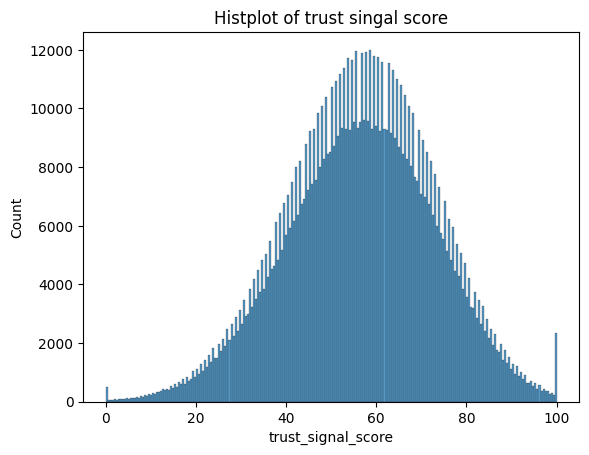

In [41]:
plt.title("Histplot of trust singal score")
sns.histplot(x="trust_signal_score",data=df)
plt.show()

### Fraud score 

In [42]:
df["fraud_score"].describe()

count    1000000.000000
mean          34.012258
std           21.371783
min            0.000000
25%           18.100000
50%           32.300000
75%           47.800000
max          100.000000
Name: fraud_score, dtype: float64

In [68]:
df["fraud_score"].value_counts(normalize=True)*100

fraud_score
0.0      5.1586
100.0    0.4126
25.3     0.1950
33.0     0.1927
27.5     0.1912
          ...  
99.1     0.0039
99.5     0.0038
99.7     0.0037
99.2     0.0034
99.8     0.0033
Name: proportion, Length: 1001, dtype: float64

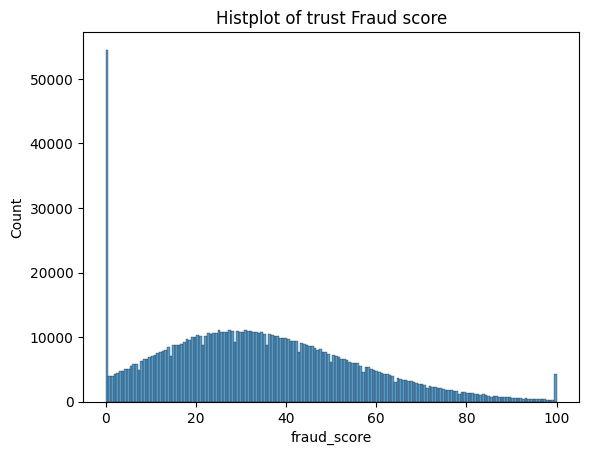

In [43]:
plt.title("Histplot of trust Fraud score")
sns.histplot(x="fraud_score",data=df)
plt.show()

### Is fake posting 

In [39]:
df["is_fake_posting"].value_counts(normalize=True)*100

is_fake_posting
0    77.8042
1    22.1958
Name: proportion, dtype: float64

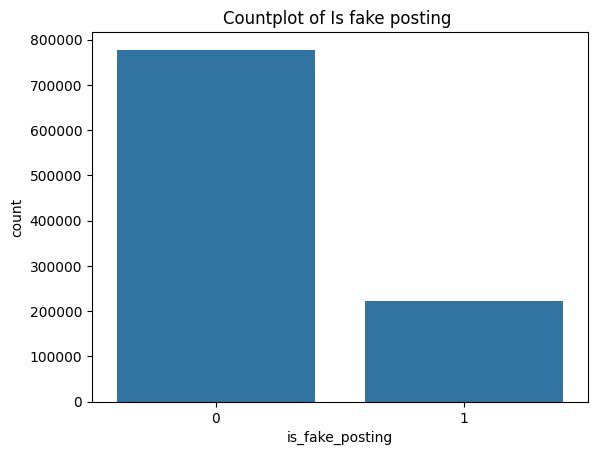

In [51]:
plt.title("Countplot of Is fake posting ")
sns.countplot(x="is_fake_posting",data=df )
plt.show()

# Biavariant analysis

Target columns: is_fake_posting

#### Objective:
Understanding the relationship between target column and orther features.

#### Internship title and is_fake_posting
+ For each internship topic the ratio of fake is identica.

#### Categorical columns vs Target column


In [4]:
ct = pd.crosstab(
    df["internship_title"],
    df["is_fake_posting"],
    normalize="index"
) * 100

In [5]:
ct 

is_fake_posting,0,1
internship_title,,
AI Research Intern,77.897722,22.102278
Backend Developer,77.716176,22.283824
Cloud Engineer,77.717479,22.282521
Cybersecurity Analyst,77.891184,22.108816
Data Science Intern,77.664658,22.335342
Frontend Developer,78.003635,21.996365
ML Engineer,77.680104,22.319896
Marketing Intern,77.874472,22.125528
UI/UX Designer,77.791443,22.208557


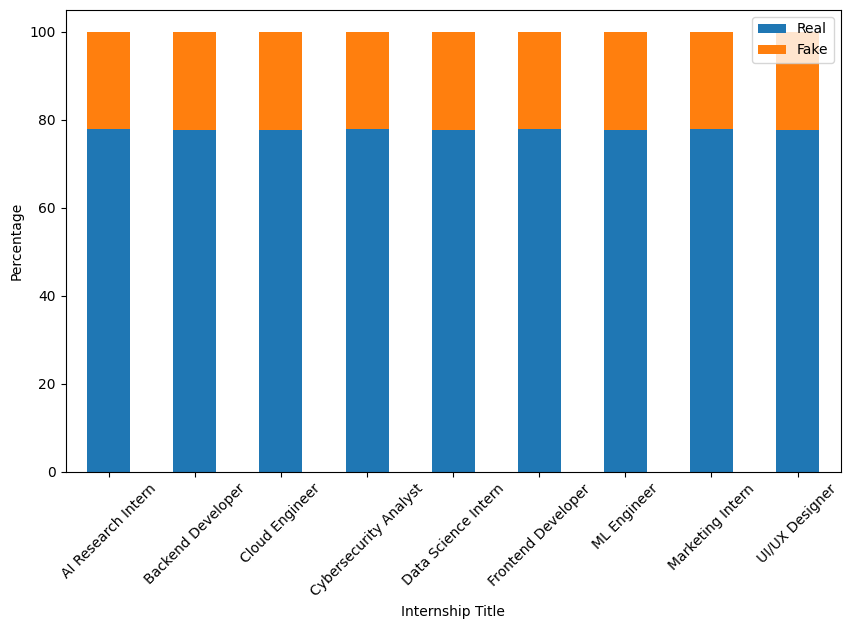

In [6]:
ct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.ylabel("Percentage")
plt.xlabel("Internship Title")
plt.legend(["Real", "Fake"])
plt.xticks(rotation=45)
plt.show()

#### Employment type and is_fake_post

In [7]:
emp_ct = pd.crosstab(
    df["employment_type"],
    df["is_fake_posting"],
    normalize="index" 
)*100 

emp_ct 

is_fake_posting,0,1
employment_type,,
Contract,77.872303,22.127697
Full-Time,77.766161,22.233839
Internship,77.805822,22.194178
Part-Time,77.772637,22.227363


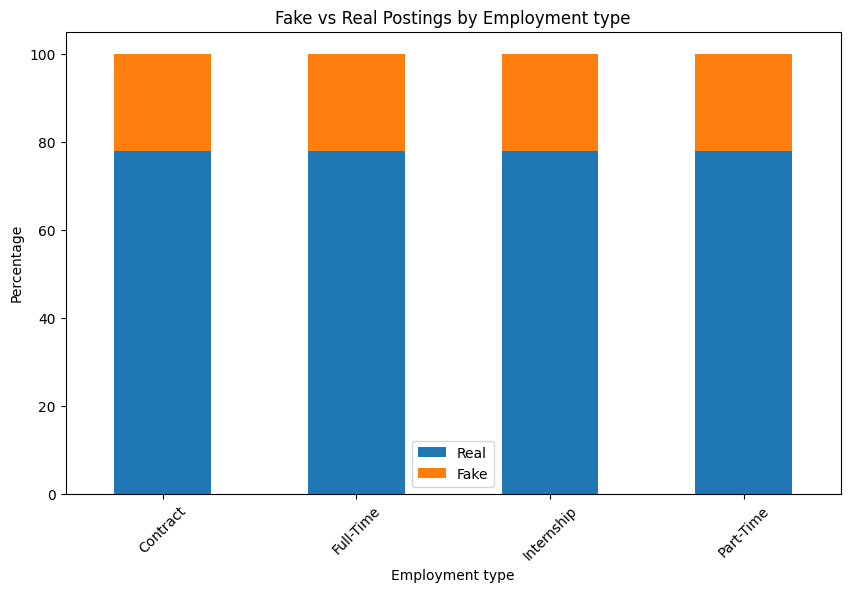

In [8]:
emp_ct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.ylabel("Percentage")
plt.xlabel("Employment type")
plt.title("Fake vs Real Postings by Employment type")
plt.legend(["Real", "Fake"])
plt.xticks(rotation=45)
plt.show()

### Word mode and is_fake_posting 

In [9]:
wrk_md_ct = pd.crosstab(
    df["work_mode"],
    df["is_fake_posting"],
    normalize="index" 
)*100 

wrk_md_ct

is_fake_posting,0,1
work_mode,,
Hybrid,80.552518,19.447482
Onsite,80.431209,19.568791
Remote,75.593759,24.406241


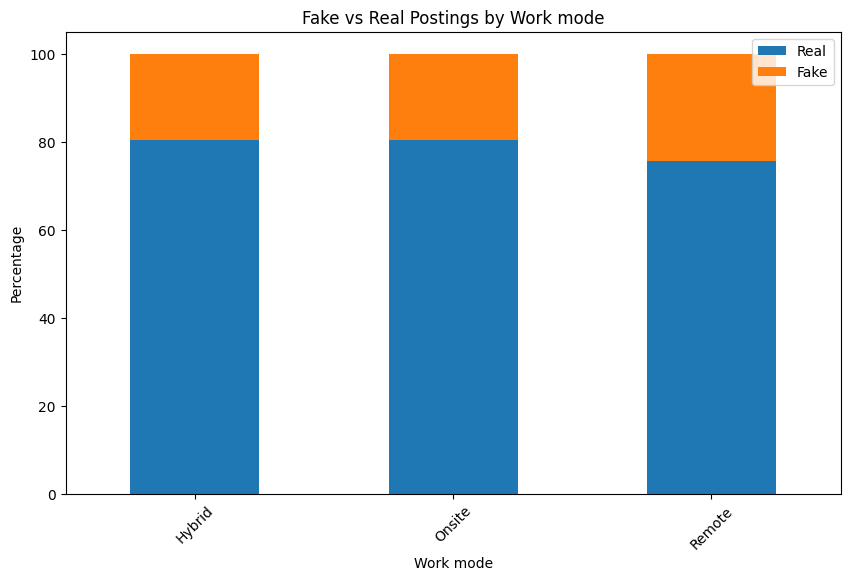

In [10]:
wrk_md_ct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.ylabel("Percentage")
plt.xlabel("Work mode")
plt.title("Fake vs Real Postings by Work mode")
plt.legend(["Real", "Fake"])
plt.xticks(rotation=45)
plt.show()

#### Industry vs is_fake_posting 

In [11]:
in_ct = pd.crosstab(
    df["industry"],
    df["is_fake_posting"],
    normalize="index" 
)*100 

In [12]:
in_ct 

is_fake_posting,0,1
industry,,
AI,77.752833,22.247167
Cybersecurity,77.788200,22.211800
E-Commerce,77.902284,22.097716
EdTech,77.801413,22.198587
FinTech,77.664490,22.335510
Gaming,77.881713,22.118287
Healthcare,77.770594,22.229406
Marketing,77.847845,22.152155
Software,77.829045,22.170955


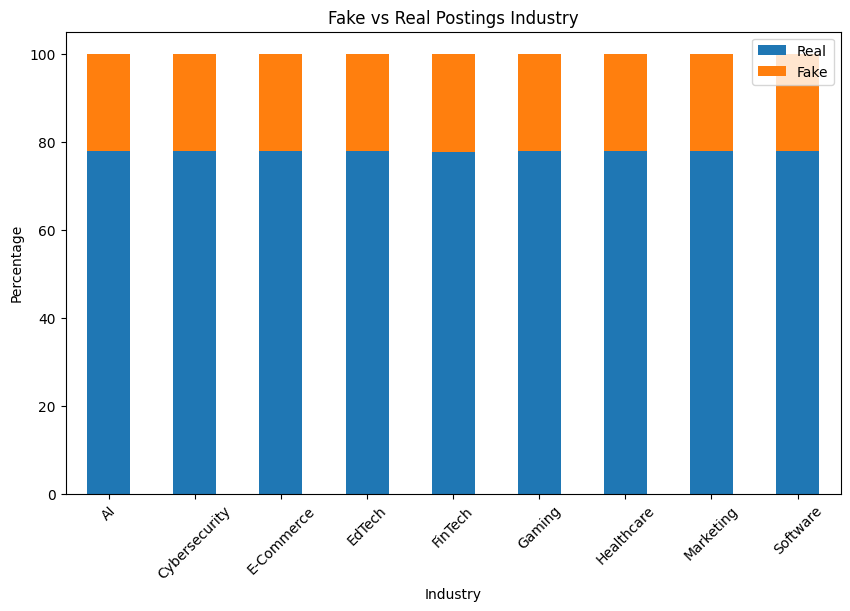

In [14]:
in_ct.plot(
        kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.ylabel("Percentage")
plt.xlabel("Industry")
plt.title("Fake vs Real Postings Industry")
plt.legend(["Real", "Fake"])
plt.xticks(rotation=45)
plt.show()

#### Location and is_fake_posting 

In [15]:
loc_ct = pd.crosstab(
    df["location"],
    df["is_fake_posting"],
    normalize="index"
)*100

In [16]:
loc_ct

is_fake_posting,0,1
location,,
Bangalore,77.427518,22.572482
Berlin,77.789891,22.210109
Dubai,77.746042,22.253958
London,77.896058,22.103942
New York,77.796471,22.203529
San Francisco,77.796930,22.203070
Singapore,77.781786,22.218214
Sydney,77.919656,22.080344
Toronto,78.083371,21.916629


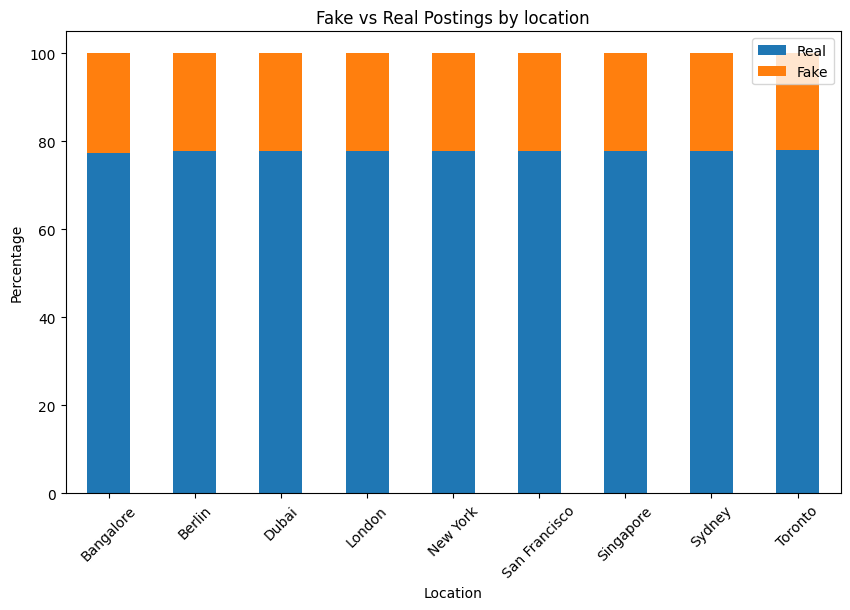

In [ ]:
loc_ct.plot(
        kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.ylabel("Percentage")
plt.xlabel("Location")
plt.title("Fake vs Real Postings by location")
plt.legend(["Real", "Fake"])
plt.xticks(rotation=45)
plt.show()

#### Company size and is_fake_posting 

In [18]:
com_ct=pd.crosstab(
    df["company_size"],
    df["is_fake_posting"],
    normalize="index"
)*100
com_ct 

is_fake_posting,0,1
company_size,,
Enterprise,77.811253,22.188747
Medium,77.902826,22.097174
Small,77.759308,22.240692
Startup,77.763512,22.236488


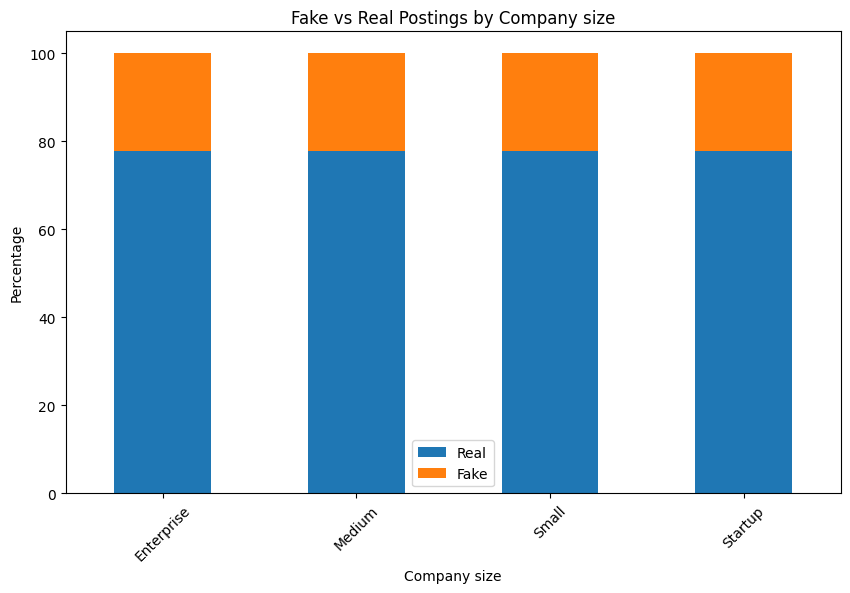

In [19]:
com_ct.plot(
        kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.ylabel("Percentage")
plt.xlabel("Company size")
plt.title("Fake vs Real Postings by Company size")
plt.legend(["Real", "Fake"])
plt.xticks(rotation=45)
plt.show()

#### Linkedin presence and is_fake_posting

+ 82% company post aren't fake is there presence is in linkedin. 

In [20]:
lin_ct = pd.crosstab(
    df["linkedin_presence"],
    df["is_fake_posting"],
    normalize="index"
) * 100 
lin_ct

is_fake_posting,0,1
linkedin_presence,,
0,60.567869,39.432131
1,82.092726,17.907274


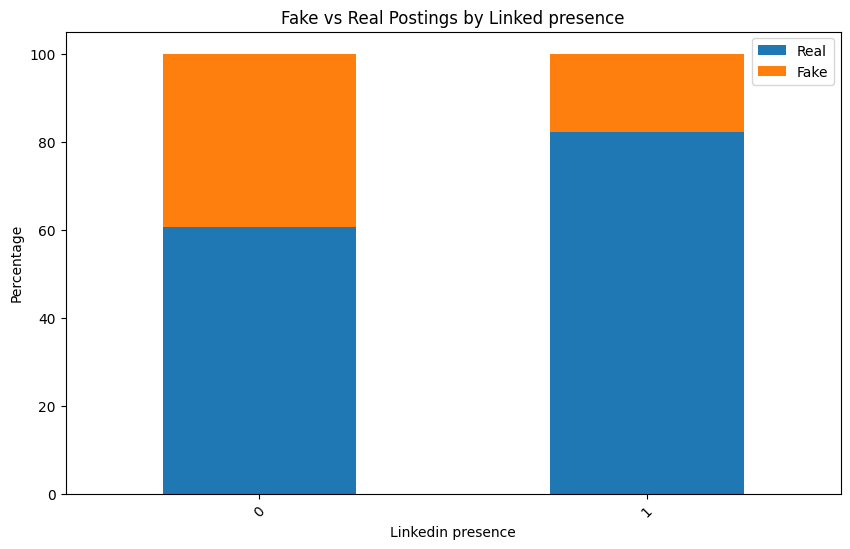

In [21]:
lin_ct.plot(
        kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.ylabel("Percentage")
plt.xlabel("Linkedin presence")
plt.title("Fake vs Real Postings by Linked presence")
plt.legend(["Real", "Fake"])
plt.xticks(rotation=45)
plt.show()

In [42]:
df[["linkedin_presence","is_fake_posting"]].corr()

,linkedin_presence,is_fake_posting
linkedin_presence,1.00000,-0.20689
is_fake_posting,-0.20689,1.00000


#### Website available and is_fake_posting 
+ We can consider that if the company website available then verified post is around 81%.

In [22]:
web_ct = pd.crosstab(
    df["website_available"],
    df["is_fake_posting"],
    normalize="index"
) * 100

web_ct

is_fake_posting,0,1
website_available,,
0,59.095231,40.904769
1,81.116223,18.883777


In [43]:
df[["website_available","is_fake_posting"]].corr()

,website_available,is_fake_posting
website_available,1.000000,-0.189424
is_fake_posting,-0.189424,1.000000


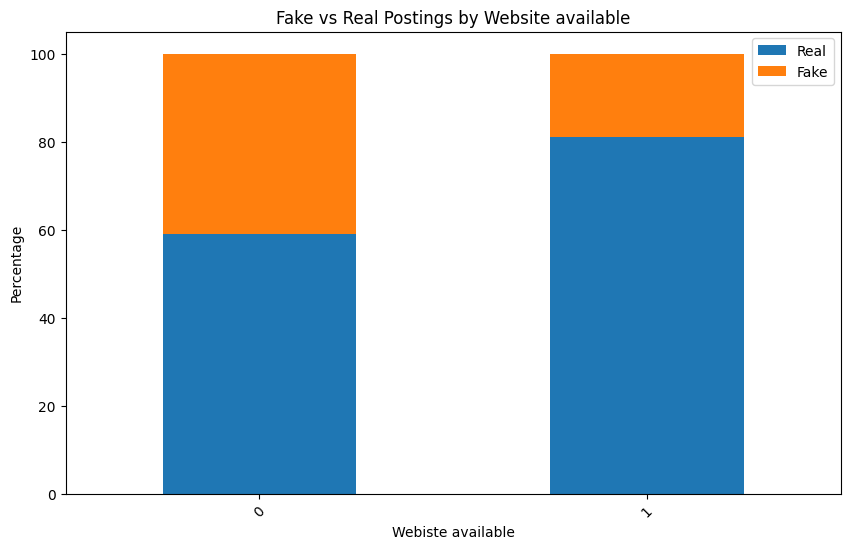

In [23]:
web_ct.plot(
        kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.ylabel("Percentage")
plt.xlabel("Webiste available")
plt.title("Fake vs Real Postings by Website available")
plt.legend(["Real", "Fake"])
plt.xticks(rotation=45)
plt.show()

#### Verfication status and is_fake_posting 

In [24]:
ver_ct = pd.crosstab(df["verification_status"],df["is_fake_posting"],normalize="index")*100

ver_ct 

is_fake_posting,0,1
verification_status,,
0,75.154436,24.845564
1,78.941366,21.058634


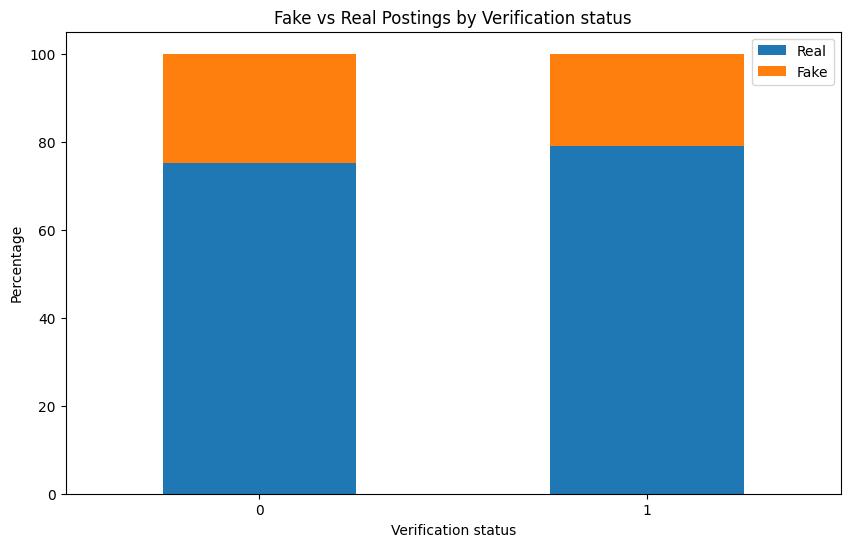

In [33]:
ver_ct.plot(
        kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.ylabel("Percentage")
plt.xlabel("Verification status")
plt.title("Fake vs Real Postings by Verification status")
plt.legend(["Real", "Fake"])
plt.xticks(rotation=0)
plt.show()

#### Payment required and Is_fake_posting

In [26]:
pay_ct =  pd.crosstab(df["payment_required"],df["is_fake_posting"],normalize="index")*100

In [27]:
pay_ct

is_fake_posting,0,1
payment_required,,
0,82.984574,17.015426
1,31.131575,68.868425


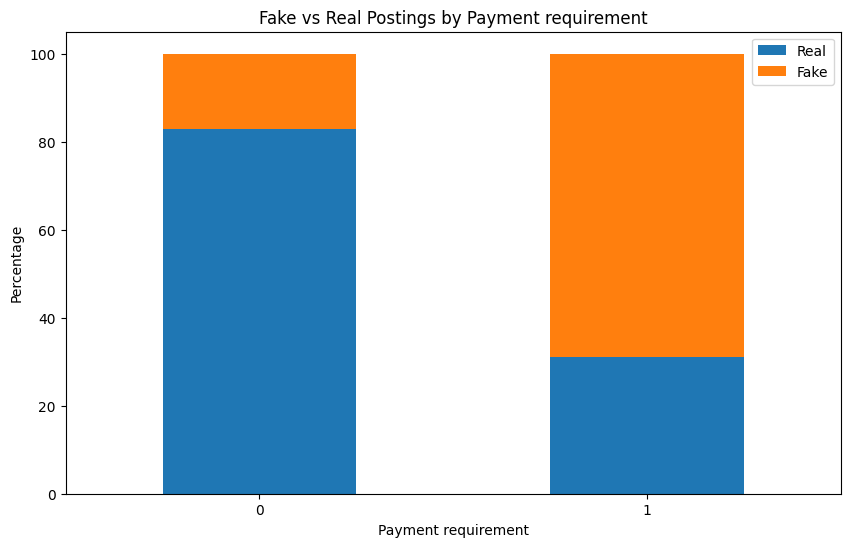

In [34]:
pay_ct.plot(
        kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.ylabel("Percentage")
plt.xlabel("Payment requirement")
plt.title("Fake vs Real Postings by Payment requirement")
plt.legend(["Real", "Fake"])
plt.xticks(rotation=0)
plt.show()

#### fake certificate offer and is_fake_posting 

In [35]:
fk_ct = pd.crosstab(df["fake_certificate_offer"],df["is_fake_posting"],normalize="index")*100

In [36]:
fk_ct 

is_fake_posting,0,1
fake_certificate_offer,,
0,80.326135,19.673865
1,48.734811,51.265189


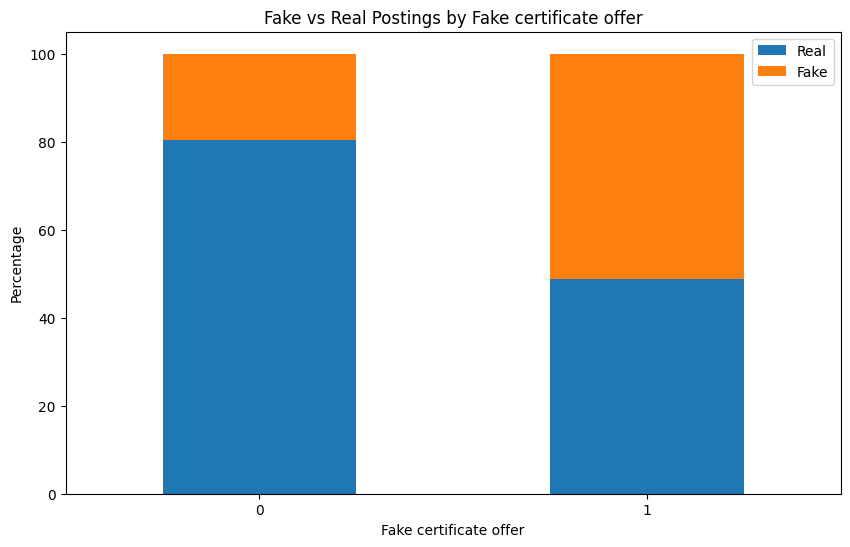

In [37]:
fk_ct.plot(
        kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.ylabel("Percentage")
plt.xlabel("Fake certificate offer")
plt.title("Fake vs Real Postings by Fake certificate offer")
plt.legend(["Real", "Fake"])
plt.xticks(rotation=0)
plt.show()

#### recruiter_email_type and is_fake_posting 

In [38]:
rc_ct = pd.crosstab(df["recruiter_email_type"],df["is_fake_posting"],normalize="index")*100

In [39]:
rc_ct

is_fake_posting,0,1
recruiter_email_type,,
Corporate,83.086280,16.913720
Free,62.005771,37.994229


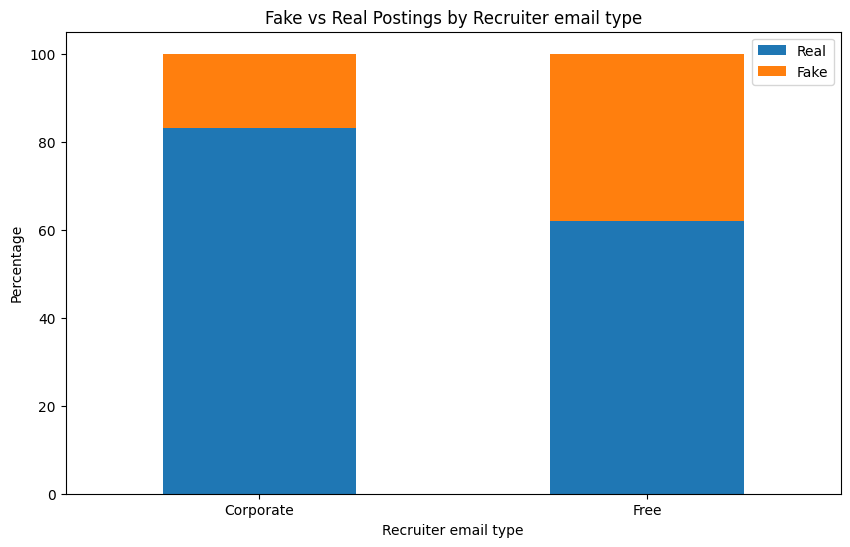

In [40]:
rc_ct.plot(
        kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.ylabel("Percentage")
plt.xlabel("Recruiter email type")
plt.title("Fake vs Real Postings by Recruiter email type")
plt.legend(["Real", "Fake"])
plt.xticks(rotation=0)
plt.show()

#### is_fake_posting and social_media_presence

In [41]:
sc_ct = pd.crosstab(df["is_fake_posting"],df["social_media_presence"],normalize="index")*100

In [42]:
sc_ct 

social_media_presence,0,1
is_fake_posting,,
0,24.984384,75.015616
1,25.144847,74.855153


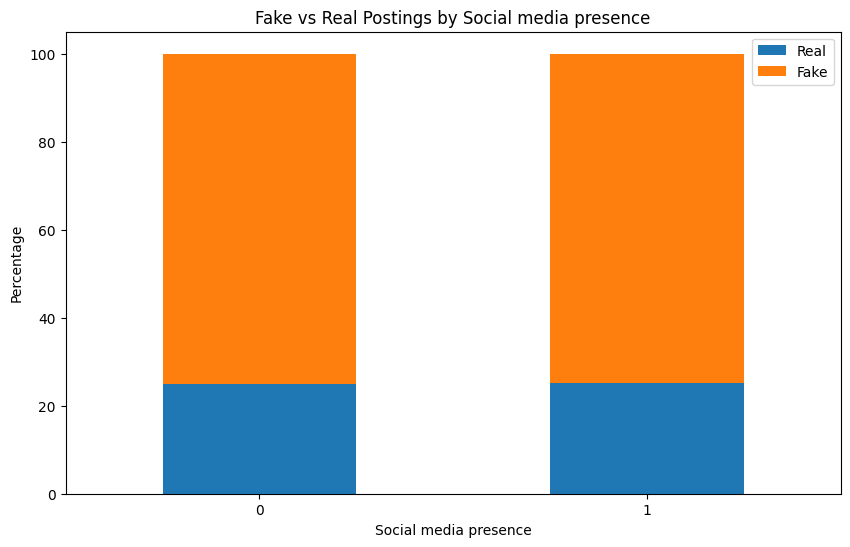

In [43]:
sc_ct.plot(
        kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.ylabel("Percentage")
plt.xlabel("Social media presence")
plt.title("Fake vs Real Postings by Social media presence")
plt.legend(["Real", "Fake"])
plt.xticks(rotation=0)
plt.show()

#### suspicious_email_domain and is_fake_posting 

In [44]:
sus_ct = pd.crosstab(df["suspicious_email_domain"],df["is_fake_posting"],normalize="index")*100

In [45]:
sus_ct

is_fake_posting,0,1
suspicious_email_domain,,
0,83.086280,16.913720
1,62.005771,37.994229


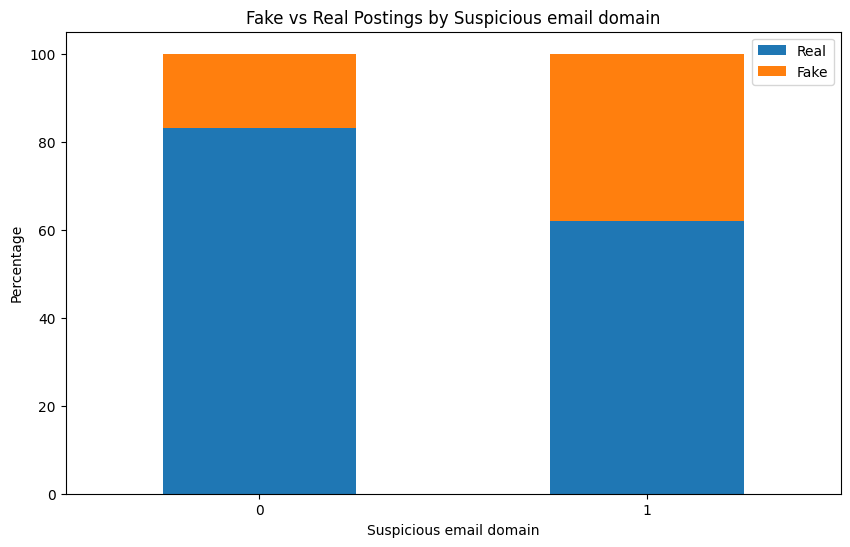

In [46]:
sus_ct.plot(
        kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.ylabel("Percentage")
plt.xlabel("Suspicious email domain")
plt.title("Fake vs Real Postings by Suspicious email domain")
plt.legend(["Real", "Fake"])
plt.xticks(rotation=0)
plt.show()

### Numerical columns vs Target column

#### Company age and is_fake_posting

In [51]:
df.groupby("is_fake_posting")["company_age"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,770242.0,20.178987,11.159887,1.0,11.0,20.0,30.0,39.0
1,219758.0,19.373443,11.547607,1.0,9.0,19.0,29.0,39.0


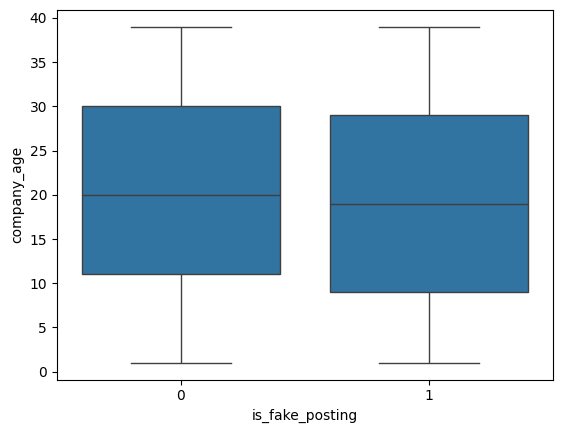

In [49]:
sns.boxplot(x="is_fake_posting", y="company_age", data=df)
plt.xticks(rotation=0)
plt.show()

#### 

In [7]:
df[["company_age","is_fake_posting"]].corr()

,company_age,is_fake_posting
company_age,1.000000,-0.029751
is_fake_posting,-0.029751,1.000000


#### Domain age in months and is_fake_posting 

In [11]:
df.groupby("is_fake_posting")["domain_age_months"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,778042.0,241.672063,134.636149,1.0,126.0,242.0,357.0,500.0
1,221958.0,232.071806,139.274324,1.0,110.0,232.0,352.0,500.0


In [12]:
df[["domain_age_months","is_fake_posting"]].corr()

,domain_age_months,is_fake_posting
domain_age_months,1.000000,-0.029391
is_fake_posting,-0.029391,1.000000


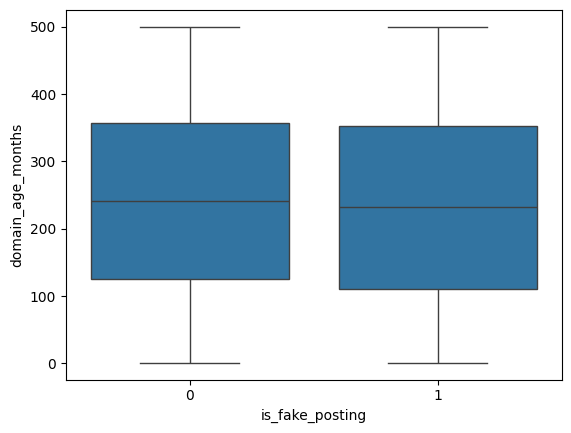

In [53]:
sns.boxplot(
    x="is_fake_posting",
    y="domain_age_months",
    data=df
)
plt.show()

#### Stipend  and is_fake_posting 

In [13]:
df.groupby("is_fake_posting")["stipend"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,770238.0,35072.25977,14823.214669,2000.0,24857.0,34988.0,45121.0,110428.0
1,219762.0,35044.95319,14854.039146,2000.0,24794.0,34966.5,45145.0,98828.0


In [14]:
df[["is_fake_posting","stipend"]].corr()

,is_fake_posting,stipend
is_fake_posting,1.000000,-0.000765
stipend,-0.000765,1.000000


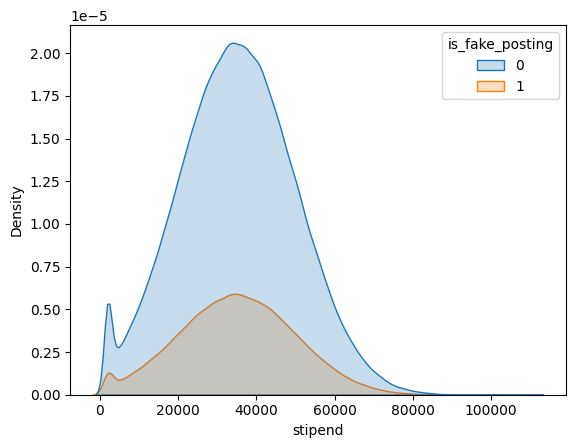

In [54]:
sns.kdeplot(
    data=df,
    x="stipend",
    hue="is_fake_posting",
    fill=True
)
plt.show()

#### Registration fee and is_fake_posting 

In [18]:
df.groupby("is_fake_posting")["registration_fee"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,778042.0,100.718000,570.515893,0.0,0.0,0.0,0.0,4999.0
1,221958.0,782.671654,1413.439637,0.0,0.0,0.0,1005.0,4999.0


In [19]:
df[["is_fake_posting","registration_fee"]].corr()

,is_fake_posting,registration_fee
is_fake_posting,1.000000,0.321503
registration_fee,0.321503,1.000000


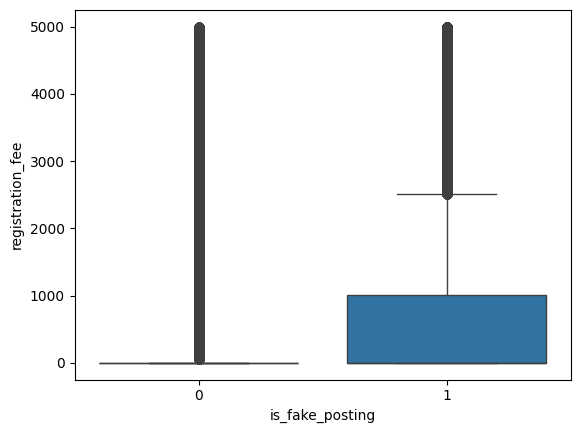

In [56]:
sns.boxplot(
    data=df,
    y="registration_fee",
    x="is_fake_posting",
)
plt.show()

#### Job description lenght and is_fake_posting 

In [20]:
df.groupby("is_fake_posting")["job_description_length"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,778042.0,1799.707489,598.697333,100.0,1394.0,1799.0,2203.0,5000.0
1,221958.0,1798.945341,598.093551,100.0,1395.0,1799.0,2202.0,4521.0


In [23]:
df[["is_fake_posting","job_description_length"]].corr()

,is_fake_posting,job_description_length
is_fake_posting,1.000000,-0.000529
job_description_length,-0.000529,1.000000


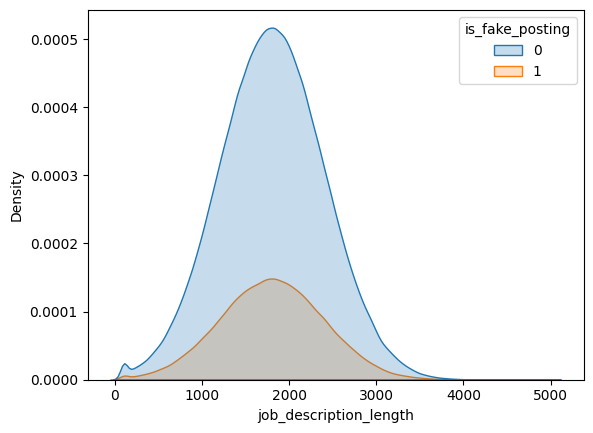

In [57]:
sns.kdeplot(
    data=df,
    x="job_description_length",
    hue="is_fake_posting",
    fill=True
)
plt.show()

#### grammatical_errors and is_fake_posting 

In [58]:
df.groupby("is_fake_posting")["grammatical_errors"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,778042.0,2.896484,1.691482,0.0,2.0,3.0,4.0,13.0
1,221958.0,3.357568,1.821530,0.0,2.0,3.0,4.0,14.0


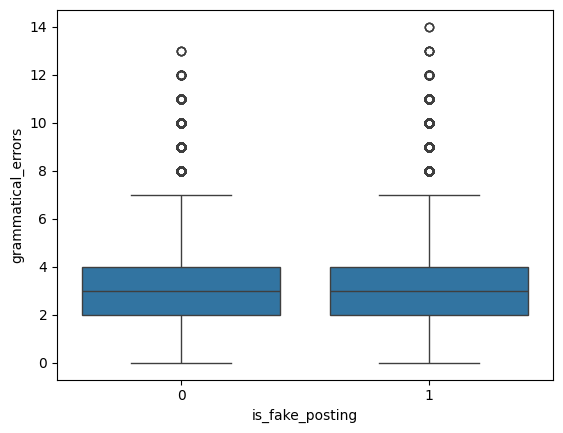

In [61]:
sns.boxplot(
    x="is_fake_posting",
    y="grammatical_errors",
    data=df
)
plt.show()

#### vague_description_score and is_fake_posting 

In [3]:
df.groupby("is_fake_posting")["vague_description_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,778042.0,27.689492,18.014905,0.0,14.0,27.0,40.0,100.0
1,221958.0,38.694185,19.054468,0.0,26.0,39.0,52.0,100.0


In [4]:
df[["is_fake_posting","vague_description_score"]].corr()

,is_fake_posting,vague_description_score
is_fake_posting,1.000000,0.243059
vague_description_score,0.243059,1.000000


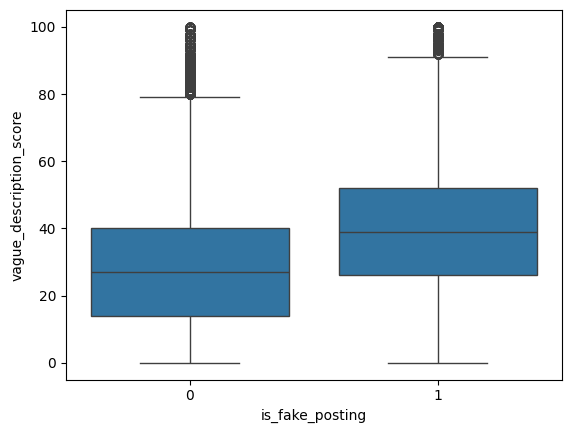

In [7]:
sns.boxplot(
    x="is_fake_posting",
    y="vague_description_score",
    data=df
)
plt.show()

#### urgency_score and is_fake_posting 

In [34]:
df.groupby("is_fake_posting")["urgency_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,778042.0,38.261753,23.243844,0.0,21.0,38.0,54.0,100.0
1,221958.0,46.305788,23.828170,0.0,29.0,46.0,63.0,100.0


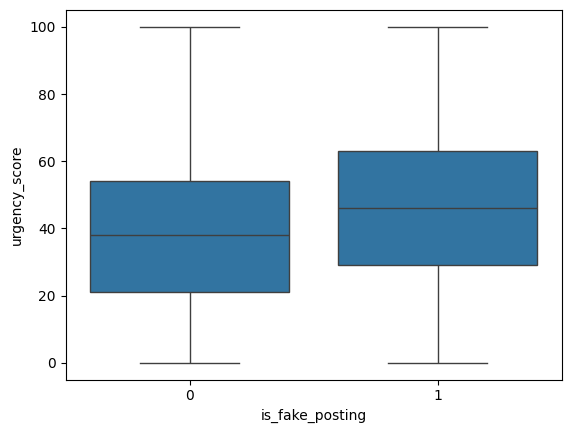

In [12]:
sns.boxplot(
    x="is_fake_posting",
    y="urgency_score",
    data=df
)
plt.show()

#### keyword_spam_score and is_fake_posting 

In [36]:
df.groupby("is_fake_posting")["keyword_spam_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,778042.0,24.507768,17.797518,0.0,10.0,23.0,37.0,100.0
1,221958.0,29.310892,18.719084,0.0,15.0,29.0,42.0,100.0


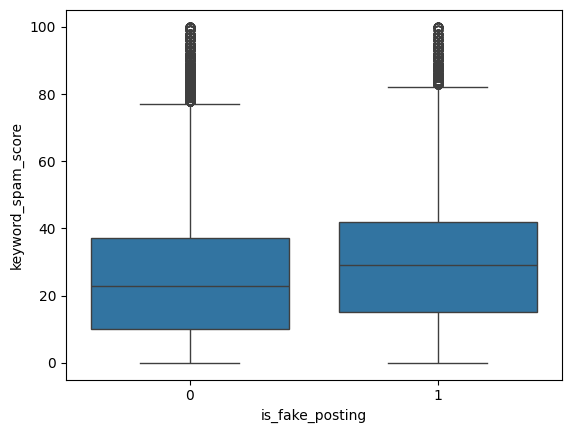

In [13]:
sns.boxplot(
    y="keyword_spam_score",
    x="is_fake_posting",
    data=df
)
plt.show()

#### recruiter_experience_years and is_fake_posting 

In [45]:
df.groupby('is_fake_posting')["recruiter_experience_years"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,778042.0,5.054950,2.871846,0.0,3.0,5.0,7.0,19.6
1,221958.0,5.044634,2.871146,0.0,3.0,5.0,7.0,17.9


In [6]:
df[["is_fake_posting","recruiter_experience_years"]].corr()

,is_fake_posting,recruiter_experience_years
is_fake_posting,1.000000,-0.001493
recruiter_experience_years,-0.001493,1.000000


#### recruiter_response_time_hours and is_fake_posting 

In [ ]:
df.groupby("is_fake_posting")["recruiter_response_time_hours"].describe()


,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,778042.0,18.178261,9.613447,1.0,11.2,18.0,24.8,63.9
1,221958.0,18.188199,9.602666,1.0,11.3,18.0,24.7,63.5


#### emotional_manipulation_score and is_fake_posting 

In [4]:
df.groupby("is_fake_posting")["emotional_manipulation_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,778042.0,25.567554,18.126427,0.0,11.0,24.0,38.0,100.0
1,221958.0,25.550816,18.142544,0.0,11.0,24.0,38.0,100.0


In [5]:
df[["emotional_manipulation_score","is_fake_posting"]].corr()


,emotional_manipulation_score,is_fake_posting
emotional_manipulation_score,1.000000,-0.000384
is_fake_posting,-0.000384,1.000000


#### phishing_language_score and is_fake_posting 

In [9]:
df.groupby("is_fake_posting")["phishing_language_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,778042.0,18.386226,14.811213,0.0,5.0,17.0,29.0,100.0
1,221958.0,29.032664,16.720489,0.0,17.0,29.0,41.0,100.0


<Axes: xlabel='phishing_language_score', ylabel='Density'>

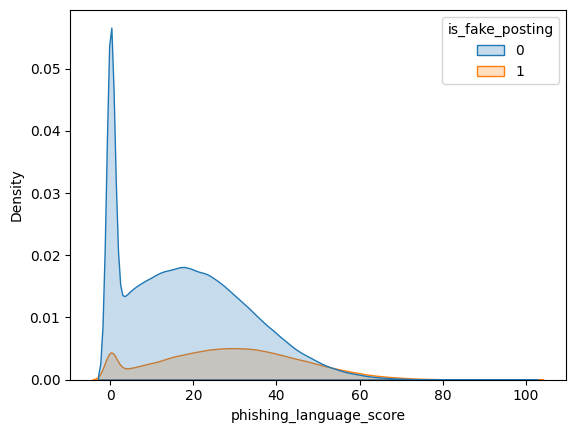

In [12]:
sns.kdeplot(
    hue="is_fake_posting",
    x="phishing_language_score",
    data=df,
    fill=True
)

#### trust_signal_score and is_fake_posting 

In [13]:
df.groupby("is_fake_posting")["trust_signal_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,770280.0,59.933052,14.967878,0.0,49.7,60.1,70.3,100.0
1,219720.0,44.716264,15.515271,0.0,34.2,44.8,55.3,100.0


In [15]:
df[["is_fake_posting","trust_signal_score"]].corr()

,is_fake_posting,trust_signal_score
is_fake_posting,1.000000,-0.386458
trust_signal_score,-0.386458,1.000000


<Axes: xlabel='trust_signal_score', ylabel='Density'>

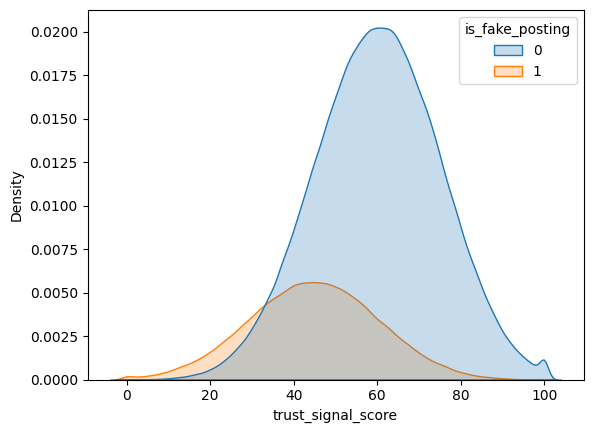

In [7]:
sns.kdeplot(
    x="trust_signal_score",
    hue="is_fake_posting",
    data=df,
    fill=True
)

#### fraud_score and is_fake_posting 

In [16]:
df.groupby('is_fake_posting')["fraud_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fake_posting,,,,,,,,
0,778042.0,25.293890,14.237469,0.0,14.4,26.2,37.0,50.0
1,221958.0,64.573251,12.118738,50.0,55.0,61.4,71.1,100.0


<Axes: xlabel='fraud_score', ylabel='Density'>

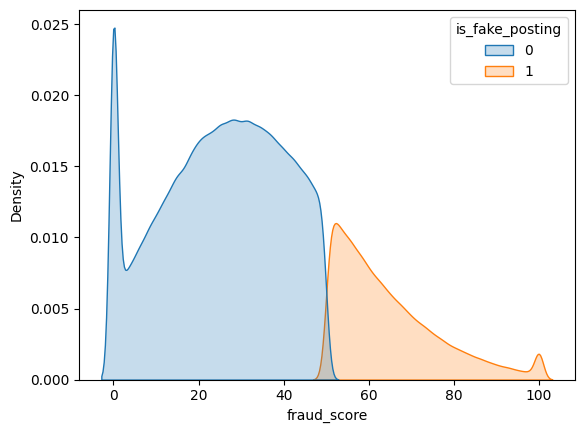

In [6]:
sns.kdeplot(
    x="fraud_score",
    hue="is_fake_posting",
    data=df,
    fill=True
)

In [17]:
df[["is_fake_posting","fraud_score"]].corr()

,is_fake_posting,fraud_score
is_fake_posting,1.000000,0.763767
fraud_score,0.763767,1.000000


In [ ]:
# List of drop columns:
# internship,employment,industry,location, company size,social media presence,
# company age,domain age,stipend,job description lenght,grammatical errors,recruiter experience years,
# Recruiter response time ,emotional manipulation,

In [31]:
# droping the columns which has almost zero imapct on target columns
df.drop(
    ['internship_title',
    'employment_type',
    'industry',
    'location', 'company_name',
     'company_size', 
     'company_age',
      'social_media_presence',
      'domain_age_months',
      'stipend',
      'job_description_length',
      'grammatical_errors',
      'recruiter_experience_years',
      'recruiter_response_time_hours',
      'emotional_manipulation_score',
     ],
    axis=1,
    inplace=True)

In [32]:
df.head()

,posting_date,work_mode,linkedin_presence,website_available,verification_status,unrealistic_salary_flag,payment_required,registration_fee,vague_description_score,urgency_score,keyword_spam_score,fake_certificate_offer,recruiter_email_type,suspicious_email_domain,phishing_language_score,trust_signal_score,fraud_score,is_fake_posting
0,2026-09-10,Remote,1,1,1,0,0,0,42,14,15,0,Free,1,28,48.4,51.8,1
1,2020-05-10,Onsite,0,1,1,0,0,0,51,29,14,1,Free,1,27,47.6,75.3,1
2,2021-07-18,Hybrid,1,1,1,0,0,0,0,5,26,0,Free,1,18,98.8,0.0,0
3,2021-02-04,Remote,1,1,1,0,0,0,21,6,30,0,Corporate,0,0,72.2,11.0,0
4,2020-12-31,Onsite,0,1,1,0,0,0,44,0,19,0,Free,1,50,34.4,56.0,1


In [33]:
df.columns

Index(['posting_date', 'work_mode', 'linkedin_presence', 'website_available',
       'verification_status', 'unrealistic_salary_flag', 'payment_required',
       'registration_fee', 'vague_description_score', 'urgency_score',
       'keyword_spam_score', 'fake_certificate_offer', 'recruiter_email_type',
       'suspicious_email_domain', 'phishing_language_score',
       'trust_signal_score', 'fraud_score', 'is_fake_posting'],
      dtype='str')

In [34]:
df.shape 

(1000000, 18)